<a href="https://colab.research.google.com/github/SameekshaPadigelawar/DEEP-LEARNING-PRACTICE/blob/main/DL_OBSERVATIONS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

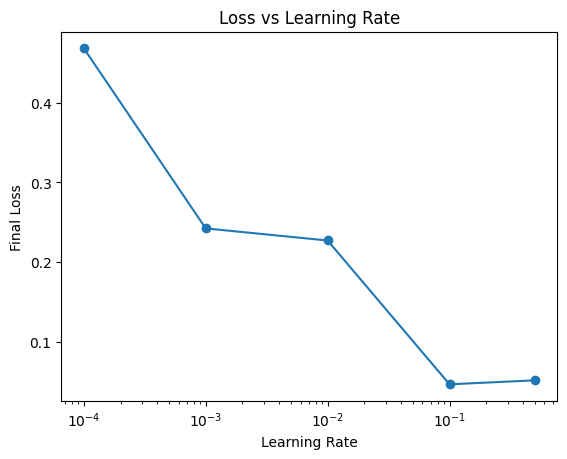

In [ ]:
#WEEK-3
import numpy as np
import matplotlib.pyplot as plt

# Create dataset (simple binary classification)
np.random.seed(0)
X = np.random.randn(200, 2)
y = (X[:, 0] * X[:, 1] > 0).astype(int).reshape(-1, 1)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# MLP Class
class MLP:
    def __init__(self):
        self.W1 = np.random.randn(2, 5)
        self.b1 = np.random.randn(1, 5)
        self.W2 = np.random.randn(5, 1)
        self.b2 = np.random.randn(1, 1)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, lr):
        error = y - output
        d_output = error * sigmoid_derivative(output)

        error_hidden = np.dot(d_output, self.W2.T)
        d_hidden = error_hidden * sigmoid_derivative(self.a1)

        self.W2 += np.dot(self.a1.T, d_output) * lr
        self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        self.W1 += np.dot(X.T, d_hidden) * lr
        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

        loss = np.mean(np.square(error))
        return loss

# Learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
losses = []

# Training loop
for lr in learning_rates:
    model = MLP()
    epochs = 200

    for _ in range(epochs):
        output = model.forward(X)
        loss = model.backward(X, y, output, lr)

    losses.append(loss)

# Plot Loss vs Learning Rate
plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.show()

np.random.seed(0)
This sets the seed for numpy's random number generator. This ensures that the "random" numbers generated later will be the same every time the code is run, making the results reproducible.

X = np.random.randn(200, 2)
This creates a 2D array named X using numpy.random.randn. It generates 200 samples, each with 2 features, drawn from a standard normal distribution (mean 0, variance 1).

y = (X[:, 0] * X[:, 1] > 0).astype(int).reshape(-1, 1)
This line creates the target labels y for binary classification:

X[:, 0] * X[:, 1]: Multiplies the first feature by the second feature for each sample.
> 0: Creates a boolean array where True if the product is positive, False otherwise.
.astype(int): Converts the boolean array to integers (True becomes 1, False becomes 0).
.reshape(-1, 1): Reshapes the array into a column vector (200 rows, 1 column), which is a common format for target labels in machine learning.
# Activation functions
Comment indicating the definition of activation functions.

def sigmoid(x):
    return 1 / (1 + np.exp(-x))
This defines the sigmoid activation function, which squashes any real-valued number into a range between 0 and 1. It's often used in the output layer of binary classification problems or in hidden layers.

def sigmoid_derivative(x):
    return x * (1 - x)
This defines the derivative of the sigmoid function. This specific form (x * (1 - x)) is used when x is already the output of the sigmoid function (i.e., sigmoid(z)). It's crucial for the backpropagation algorithm.

# MLP Class
Comment indicating the definition of the Multi-Layer Perceptron (MLP) class.

class MLP:
This declares a Python class named MLP, which will encapsulate the structure and behavior of our neural network.

    def __init__(self):
This is the constructor method for the MLP class. It's called when a new MLP object is created.

        self.W1 = np.random.randn(2, 5)
Initializes the weight matrix W1 for the first layer (input to hidden layer). It has dimensions (2, 5) because there are 2 input features and 5 hidden neurons.

        self.b1 = np.random.randn(1, 5)
Initializes the bias vector b1 for the hidden layer. It has dimensions (1, 5) because there's one bias term for each of the 5 hidden neurons.

        self.W2 = np.random.randn(5, 1)
Initializes the weight matrix W2 for the second layer (hidden to output layer). It has dimensions (5, 1) because there are 5 hidden neurons and 1 output neuron.

        self.b2 = np.random.randn(1, 1)
Initializes the bias vector b2 for the output layer. It has dimensions (1, 1) because there's one bias term for the single output neuron.

    def forward(self, X):
This defines the forward method of the MLP class, which calculates the network's output given an input X.

        self.z1 = np.dot(X, self.W1) + self.b1
Calculates the weighted sum of inputs plus bias for the hidden layer. np.dot performs matrix multiplication of X and W1, then b1 is added (broadcasting applies).

        self.a1 = sigmoid(self.z1)
Applies the sigmoid activation function to the result of z1 to get the activation of the hidden layer, a1.

        self.z2 = np.dot(self.a1, self.W2) + self.b2
Calculates the weighted sum of inputs plus bias for the output layer, using the activated hidden layer a1.

        self.a2 = sigmoid(self.z2)
Applies the sigmoid activation function to the result of z2 to get the final output of the network, a2.

        return self.a2
Returns the network's prediction (output).

    def backward(self, X, y, output, lr):
This defines the backward method, which performs backpropagation to update the network's weights and biases. It takes input X, true labels y, the network's output (prediction), and the learning_rate (lr).

        error = y - output
Calculates the difference between the true labels (y) and the network's prediction (output), which represents the error at the output layer.

        d_output = error * sigmoid_derivative(output)
Calculates the delta (gradient) for the output layer. This is the error multiplied by the derivative of the sigmoid function applied to the output.

        error_hidden = np.dot(d_output, self.W2.T)
Propagates the error backward from the output layer to the hidden layer. It's the dot product of the output layer delta and the transpose of W2.

        d_hidden = error_hidden * sigmoid_derivative(self.a1)
Calculates the delta (gradient) for the hidden layer. This is the propagated error multiplied by the derivative of the sigmoid function applied to the hidden layer's activation (a1).

        self.W2 += np.dot(self.a1.T, d_output) * lr
Updates the weights W2. It's the dot product of the transpose of the hidden layer activations (a1.T) and the output delta, scaled by the learning rate.

        self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
Updates the biases b2. It's the sum of the output deltas across all samples, scaled by the learning rate. keepdims=True maintains the shape for correct broadcasting.

        self.W1 += np.dot(X.T, d_hidden) * lr
Updates the weights W1. It's the dot product of the transpose of the input X and the hidden layer delta, scaled by the learning rate.

        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr
Updates the biases b1. It's the sum of the hidden layer deltas across all samples, scaled by the learning rate.

        loss = np.mean(np.square(error))
Calculates the mean squared error (MSE) as a measure of the network's performance. np.square squares each element of the error, and np.mean takes the average.

        return loss
Returns the calculated loss for the current iteration.

# Learning rates to test
Comment indicating the definition of learning rates for testing.

learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
Creates a list of different learning rate values that will be used to train the MLP model. A learning rate determines the step size at each iteration while moving toward a minimum of a loss function.

losses = []
Initializes an empty list to store the final loss value corresponding to each learning rate.

# Training loop
Comment indicating the start of the training process.

for lr in learning_rates:
This loop iterates through each learning rate defined in the learning_rates list.

    model = MLP()
Inside the loop, for each learning rate, a new instance of the MLP model is created. This ensures that each learning rate experiment starts with randomly initialized weights and biases, making the comparison fair.

    epochs = 200
Sets the number of training epochs (iterations) for each model to 200.

    for _ in range(epochs):
This inner loop runs for the specified number of epochs to train the current model.

        output = model.forward(X)
Performs a forward pass using the current input X to get the model's predictions.

        loss = model.backward(X, y, output, lr)
Performs a backward pass, updating the model's weights and biases based on the error and the current lr, and calculates the loss for the current epoch.

    losses.append(loss)
After 200 epochs, the final loss for the current learning rate is appended to the losses list.

# Plot Loss vs Learning Rate
Comment indicating the purpose of the following plotting code.

plt.plot(learning_rates, losses, marker='o')
Creates a line plot with learning_rates on the x-axis and the corresponding losses on the y-axis. marker='o' adds circular markers at each data point.

plt.xscale('log')
Sets the x-axis scale to logarithmic. This is useful when the x-axis values (learning rates, in this case) span several orders of magnitude.

plt.xlabel("Learning Rate")
Sets the label for the x-axis to "Learning Rate".

plt.ylabel("Final Loss")
Sets the label for the y-axis to "Final Loss".

plt.title("Loss vs Learning Rate")
Sets the title of the plot to "Loss vs Learning Rate".

plt.show()
Displays the generated plot.

/tmp/ipykernel_9847/3685103248.py:13: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


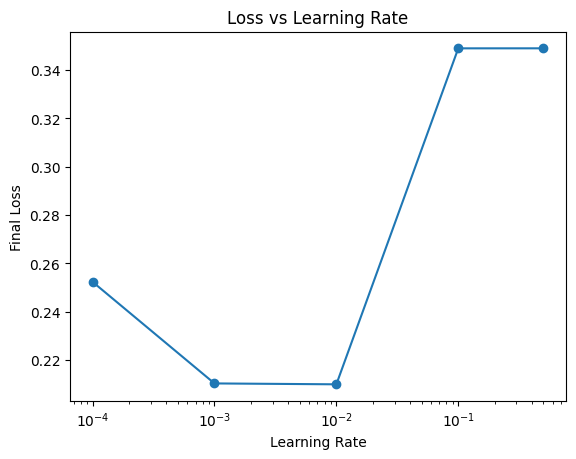

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Replace 'your_dataset.csv' with the path to your CSV file
df = pd.read_csv('diabetes_DT.csv')
# Example for X (features - ensure it's a NumPy array)
X = df.drop("Outcome",axis=1).values # Convert to numpy array
y = df['Outcome'].values.reshape(-1, 1)

# Activation functions
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

# MLP Class
class MLP:
    def __init__(self, input_size, hidden_size, output_size):
        self.W1 = np.random.randn(input_size, hidden_size)
        self.b1 = np.random.randn(1, hidden_size)
        self.W2 = np.random.randn(hidden_size, output_size)
        self.b2 = np.random.randn(1, output_size)

    def forward(self, X):
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = sigmoid(self.z1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = sigmoid(self.z2)
        return self.a2

    def backward(self, X, y, output, lr):
        error = y - output
        d_output = error * sigmoid_derivative(output)

        error_hidden = np.dot(d_output, self.W2.T)
        d_hidden = error_hidden * sigmoid_derivative(self.a1)

        self.W2 += np.dot(self.a1.T, d_output) * lr
        self.b2 += np.sum(d_output, axis=0, keepdims=True) * lr
        self.W1 += np.dot(X.T, d_hidden) * lr
        self.b1 += np.sum(d_hidden, axis=0, keepdims=True) * lr

        loss = np.mean(np.square(error))
        return loss

# Learning rates to test
learning_rates = [0.0001, 0.001, 0.01, 0.1, 0.5]
losses = []

# Determine input and output sizes from the data
input_size = X.shape[1]  # Number of features in X
hidden_size = 5          # Number of neurons in the hidden layer
output_size = y.shape[1] # Number of output neurons (1 for binary classification)

# Training loop
for lr in learning_rates:
    # Initialize MLP with correct input and output sizes
    model = MLP(input_size, hidden_size, output_size)
    epochs = 200

    for _ in range(epochs):
        output = model.forward(X)
        loss = model.backward(X, y, output, lr)

    losses.append(loss)

# Plot Loss vs Learning Rate
plt.plot(learning_rates, losses, marker='o')
plt.xscale('log')
plt.xlabel("Learning Rate")
plt.ylabel("Final Loss")
plt.title("Loss vs Learning Rate")
plt.show()



---

### 📊 What your graph is saying

* **Very small learning rate (0.0001)**
  → Loss is **higher (~0.25)**
  → Model learns **too slowly** and doesn’t converge well

* **Moderate learning rates (0.001 and 0.01)**
  → Loss is **lowest (~0.21)**
  → ✅ **Best performance**
  → Model learns efficiently and converges properly

* **Large learning rates (0.1 and 0.5)**
  → Loss **increases (~0.35)**
  → Model becomes **unstable**
  → It may be **overshooting** the optimal solution

---

### 🧠 Key Insight

👉 There is an **optimal learning rate range** (here around **0.001–0.01**)

* Too small → slow learning
* Too large → unstable / poor learning

---

### 📌 Conclusion

> The graph shows that the learning rate significantly impacts model performance. Moderate learning rates (0.001–0.01) produce the lowest loss, indicating better convergence. Very small learning rates result in slow learning, while large learning rates cause instability and higher error.




Testing Perceptron with different eta0 (learning rate) values:

  eta0: 0.0001, Accuracy: 0.6558
  eta0: 0.001, Accuracy: 0.6558
  eta0: 0.01, Accuracy: 0.6558
  eta0: 0.1, Accuracy: 0.7078
  eta0: 1.0, Accuracy: 0.7078


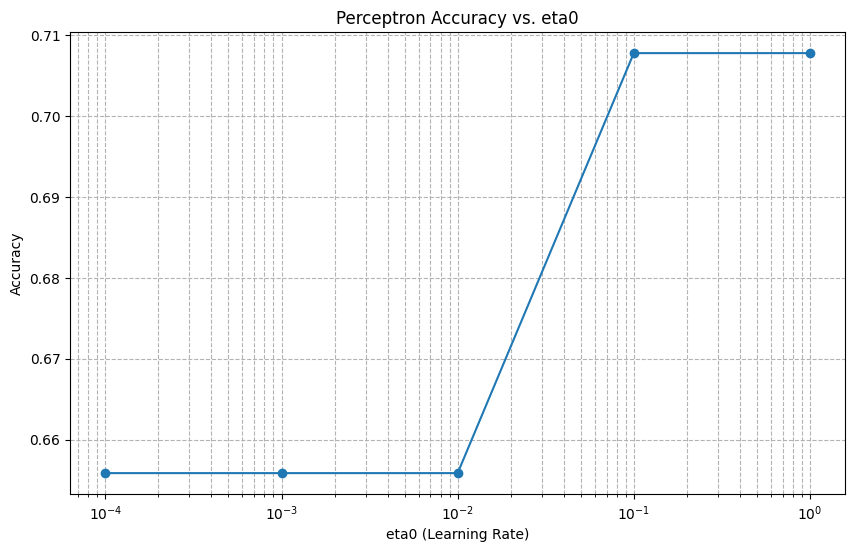

In [ ]:
from sklearn.linear_model import Perceptron
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd # Import pandas to read the CSV
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# Load your dataset
df = pd.read_csv('diabetes_DT.csv')

# Separate features (X) and target (y)
# 'Outcome' is assumed to be your target column
X = df.drop('Outcome', axis=1) # All columns except 'Outcome' are features
y = df['Outcome']              # 'Outcome' is the target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# 🔥 IMPORTANT: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Learning rates (eta0) to test
eta0_values = [0.0001, 0.001, 0.01, 0.1, 1.0]
accuracies = []

print("Testing Perceptron with different eta0 (learning rate) values:\n")
for eta0_val in eta0_values:
    # Create a Perceptron object with the current eta0
    # max_iter is set explicitly to avoid convergence warnings with default tol
    perceptron = Perceptron(eta0=eta0_val, random_state=0, max_iter=1000, tol=1e-3)

    # Train the Perceptron on the training data
    perceptron.fit(X_train, y_train)

    # Use the trained Perceptron to make predictions on the testing data
    y_pred = perceptron.predict(X_test)

    # Evaluate the accuracy of the Perceptron
    accuracy = accuracy_score(y_test, y_pred)
    accuracies.append(accuracy)
    print(f"  eta0: {eta0_val}, Accuracy: {accuracy:.4f}")

# Plot Accuracy vs eta0
plt.figure(figsize=(10, 6))
plt.plot(eta0_values, accuracies, marker='o')
plt.xscale('log')
plt.xlabel("eta0 (Learning Rate)")
plt.ylabel("Accuracy")
plt.title("Perceptron Accuracy vs. eta0")
plt.grid(True, which="both", ls="--", c='0.7')
plt.show()


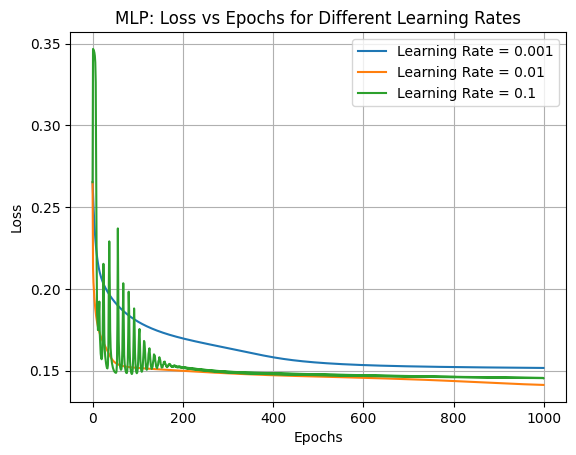

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv('diabetes_DT.csv')

# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values.reshape(-1, 1)

# Scale features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Activation functions
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# MLP Training Function
def train_mlp(learning_rate, epochs):
    np.random.seed(0)

    # ✅ FIXED HERE
    W1 = np.random.randn(X.shape[1], 3)
    b1 = np.zeros((1, 3))
    W2 = np.random.randn(3, 1)
    b2 = np.zeros((1, 1))

    losses = []

    for epoch in range(epochs):

        # Forward pass
        z1 = np.dot(X, W1) + b1
        a1 = sigmoid(z1)

        z2 = np.dot(a1, W2) + b2
        y_pred = sigmoid(z2)

        # Loss
        loss = np.mean((y - y_pred) ** 2)
        losses.append(loss)

        # Backpropagation
        error = y_pred - y

        dz2 = error * sigmoid_derivative(z2)
        dW2 = np.dot(a1.T, dz2)
        db2 = np.sum(dz2, axis=0, keepdims=True)

        dz1 = np.dot(dz2, W2.T) * sigmoid_derivative(z1)
        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis=0, keepdims=True)

        # Update
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1

    return losses

# Experiment
learning_rates = [0.001, 0.01, 0.1]
epochs = 1000

plt.figure()

for lr in learning_rates:
    losses = train_mlp(lr, epochs)
    plt.plot(losses, label=f"Learning Rate = {lr}")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("MLP: Loss vs Epochs for Different Learning Rates")
plt.legend()
plt.grid(True)
plt.show()

---

# 🧠 1. Model Type

### 🔹 Perceptron (previous code)

```python
Perceptron()
```

* **Single-layer model**
* No hidden layer
* Linear decision boundary

👉 Think:

```
Input → Output
```

---

### 🔹 MLP (current code)

```python
Input → Hidden Layer → Output
```

* Multi-layer neural network
* Has **hidden neurons**
* Can learn **complex patterns**

---

# ⚡ 2. Learning Capability

### ❌ Perceptron

* Only works for **linearly separable data**
* Example:

  * Works: straight-line separation
  * Fails: XOR-type problems

---

### ✅ MLP

* Can solve **non-linear problems**
* Example:

  * XOR ✅
  * Complex datasets ✅

---

# ⚙️ 3. Implementation

### 🔹 Perceptron (previous code)

```python
perceptron.fit(X_train, y_train)
```

👉 Everything is handled by sklearn:

* Weight updates
* Loss calculation
* Optimization

👉 You DON’T see:

* gradients
* backpropagation

---

### 🔹 MLP (current code)

You manually wrote:

```python
forward()
backward()
```

👉 You control:

* weights
* gradients
* updates

👉 This is:

```
LOW-LEVEL (educational)
```

---

# 🔁 4. Learning Process

### 🔹 Perceptron

* Uses simple rule:

```
If wrong → update weights
```

* No smooth optimization
* No probability output

---

### 🔹 MLP

* Uses:

```
Gradient Descent + Backpropagation
```

* Smooth learning
* Uses **loss function (MSE)**
* More powerful

---

# 📊 5. What You Are Plotting

### 🔹 Perceptron code

```python
Accuracy vs Learning Rate
```

👉 Final performance on test data

---

### 🔹 MLP code

```python
Loss vs Epochs
```

👉 How error reduces during training

---

# 🎯 6. Output Type

### Perceptron

* Output:

```
0 or 1 (direct classification)
```

---

### MLP

* Output:

```
0 to 1 (probability-like)
```

* You convert to class later

---

# 🔬 7. Real-world Use

### Perceptron

* Simple problems
* Educational purpose

---

### MLP

* Real-world deep learning
* Used in:

  * image recognition
  * speech processing
  * medical prediction (like diabetes)

---

# 🧾 Final Comparison Table

| Feature               | Perceptron     | MLP              |
| --------------------- | -------------- | ---------------- |
| Layers                | 1              | Multiple         |
| Hidden Layer          | ❌              | ✅                |
| Handles Non-linearity | ❌              | ✅                |
| Learning              | Simple updates | Gradient descent |
| Implementation        | sklearn        | manual           |
| Output                | 0/1            | probability      |
| Power                 | Low            | High             |

---

# 📌 Final Answer

> The Perceptron is a single-layer linear classifier that updates weights using a simple rule, whereas the MLP is a multi-layer neural network that uses backpropagation and gradient descent to learn complex non-linear relationships. The Perceptron is simpler but less powerful compared to the MLP.




In [ ]:
# WEEK-4: MLP using Optimization Algorithm (Adam)

import numpy as np
import pandas as pd
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv('diabetes_DT.csv')

# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# -----------------------------
# Train-Test Split (VERY IMPORTANT)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# -----------------------------
# Feature Scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build MLP Model
# -----------------------------
model = Sequential()
model.add(Dense(16, input_dim=X_train.shape[1], activation='sigmoid'))
model.add(Dense(1, activation='sigmoid'))

# -----------------------------
# Compile Model
# -----------------------------
model.compile(
    loss='mean_squared_error',
    optimizer='adam',
    metrics=['binary_accuracy']
)

# -----------------------------
# Train Model
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=1000,
    verbose=0
)

# -----------------------------
# Plot Loss vs Epochs
# -----------------------------
errors = history.history['loss']

df_plot = pd.DataFrame({
    "Epoch": np.arange(len(errors)),
    "Loss": errors
})

chart = alt.Chart(df_plot).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title="Loss vs Epochs")

chart.display()  # for notebooks

# -----------------------------
# Evaluate Model on Test Data
# -----------------------------
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

accuracy = (y_pred.flatten() == y_test).mean() * 100

print("Test Accuracy: %.2f%%" % accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


alt.Chart(...)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
Test Accuracy: 80.52%


In [8]:
import numpy as np
import pandas as pd
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# Load dataset
df = pd.read_csv('diabetes_DT.csv')

# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build model
model_sgd = Sequential()
model_sgd.add(Dense(256, input_dim=X_train.shape[1], activation='sigmoid'))
model_sgd.add(Dense(1, activation='sigmoid'))

# Compile model
model_sgd.compile(
    loss='mean_squared_error',
    optimizer=SGD(),
    metrics=['binary_accuracy']
)

# Train model
history_sgd = model_sgd.fit(X_train, y_train, epochs=1000, verbose=0)

# Loss values
errors_sgd = history_sgd.history['loss']

# Plot
df_sgd = pd.DataFrame({
    "Epoch": np.arange(len(errors_sgd)),
    "Loss": errors_sgd
})

alt.Chart(df_sgd).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title='SGD Optimizer - Loss Curve')

# Predictions on test data
y_pred_sgd = model_sgd.predict(X_test)
y_pred_sgd = (y_pred_sgd > 0.5).astype(int)

# Accuracy
accuracy_sgd = (y_pred_sgd.flatten() == y_test).mean() * 100

print('SGD Optimizer Accuracy: %.2f%%' % accuracy_sgd)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
SGD Optimizer Accuracy: 82.47%




# 🧠 What is SGD?

> **SGD is a method used to update weights in a neural network to reduce error.**

---

# 🎯 Goal of SGD

👉 Minimize loss (error)

---

# 🔍 Basic Idea

Think like this:

👉 Your model makes a prediction → it is wrong
👉 SGD helps **correct the weights** to reduce that error

---

# ⚙️ Simple Formula

```text
New Weight = Old Weight − Learning Rate × Gradient
```

---

# 🔥 What each term means

### 🔹 Weight

* Parameters of the model
* What we are trying to adjust

---

### 🔹 Gradient

* Direction of error
* Tells:

```text
Which way to move to reduce error
```

---

### 🔹 Learning Rate

* Step size
* How big the update should be

---

# 🧠 Why “Stochastic”?

👉 “Stochastic” means:

```text
Uses one (or few) data points at a time
```

Instead of:

* Using full dataset (slow)

It uses:

* Small chunks → faster updates

---

# 🎯 Intuition (Very Easy)

Imagine:

* You are going downhill 🏔️
* You want to reach lowest point (minimum error)

SGD does:

```text
Take small steps downhill using slope (gradient)
```

---

# 📊 Example

Prediction is wrong → error = high

SGD:

```text
Adjust weights slightly → error reduces
```

Repeat many times → model improves

---

# ⚡ Why use SGD?

✅ Simple
✅ Fast
✅ Works well for large data

---

# ❗ Limitation

* Can be **slow to converge**
* Can **jump around (unstable)**

👉 That’s why newer optimizers (like Adam) are better

---

# 📌 Final Answer (for exam)

> Stochastic Gradient Descent (SGD) is an optimization algorithm that updates model weights using the gradient of the loss function to minimize error, typically using one or a few training samples at a time.

---

# 🧠 One-line memory trick

👉 **SGD = adjust weights step-by-step using error direction**

Alright — let’s go **step by step through your corrected SGD-based MLP code**, and I’ll explain **what each line is doing + why** 👇

---

# 🧠 Big Picture First

👉 You are:

1. Loading diabetes dataset
2. Splitting into train/test
3. Scaling features
4. Building a neural network
5. Training it using **SGD optimizer**
6. Tracking loss
7. Testing accuracy

---

# 🔹 1. Import Libraries

```python
import numpy as np
import pandas as pd
import altair as alt
```

* `numpy` → numerical operations
* `pandas` → dataset handling
* `altair` → plotting graph

---

```python
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
```

* `train_test_split` → split data
* `StandardScaler` → normalize features

---

```python
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
```

* `Sequential` → neural network container
* `Dense` → fully connected layer
* `SGD` → optimization algorithm

---

# 🔹 2. Load Dataset

```python
df = pd.read_csv('diabetes_DT.csv')
```

👉 Reads CSV into a table

---

# 🔹 3. Separate Features & Target

```python
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values
```

👉 Meaning:

* `X` → input features (glucose, BMI, etc.)
* `y` → output (0 or 1)

---

# 🔹 4. Train-Test Split

```python
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
```

👉 Splits data:

* 80% → training
* 20% → testing

👉 Why?

```text
Train → learn
Test → evaluate
```

---

# 🔹 5. Feature Scaling

```python
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
```

👉 Converts data to:

* mean = 0
* std = 1

👉 Why?

* Makes training stable
* Prevents large-value features dominating

---
Good — this is the **most important part** of your whole experiment. I’ll explain the **neural network building + training part very clearly**, step by step, without confusion.

---

# 🧠 Starting Point

We begin from here in your code:

```python
model_sgd = Sequential()
model_sgd.add(Dense(16, input_dim=X_train.shape[1], activation='sigmoid'))
model_sgd.add(Dense(1, activation='sigmoid'))
```

---

# 🔴 1. What is `Sequential()`?

```python
model_sgd = Sequential()
```

👉 This creates an **empty neural network**

Think of it like:

```text
We are about to stack layers one by one
```

---

# 🔴 2. First Layer (Hidden Layer)

```python
model_sgd.add(Dense(16, input_dim=X_train.shape[1], activation='sigmoid'))
```

Let’s break this **completely** 👇

---

## 🔹 `Dense(16, ...)`

👉 “Dense” means:

```text
Every neuron is connected to every input
```

👉 `16` means:

```text
This layer has 16 neurons
```

---

## 🔹 `input_dim=X_train.shape[1]`

👉 This is **VERY IMPORTANT**

* `X_train.shape[1]` = number of features
* Example:

```text
Pregnancies, Glucose, BMI, Age → maybe 8 features
```

👉 So:

```text
Each neuron receives 8 inputs
```

---

## 🔹 What happens inside one neuron?

Each neuron does:

```text
z = (w1*x1 + w2*x2 + ... + wn*xn) + bias
```

Then:

```text
output = sigmoid(z)
```

---

## 🔹 `activation='sigmoid'`

👉 This converts output into:

```text
value between 0 and 1
```

👉 Why?

* Helps model learn non-linearity
* Works well for binary problems

---

## 🔥 So this layer does:

```text
Input (features)
   ↓
16 neurons (each does weighted sum + sigmoid)
   ↓
Output (16 values)
```

---

# 🔴 3. Output Layer

```python
model_sgd.add(Dense(1, activation='sigmoid'))
```

👉 This is final layer

---

## 🔹 `Dense(1)`

👉 Only **1 neuron**

👉 Why?

```text
Binary classification → need single output
```

---

## 🔹 What it does:

```text
Takes 16 inputs (from hidden layer)
→ combines them
→ gives one output
```

---

## 🔹 Final output:

```text
value between 0 and 1
```

Example:

```text
0.8 → diabetes
0.2 → no diabetes
```

---

# 🔥 Complete Flow of Network

```text
Input (8 features)
        ↓
Hidden Layer (16 neurons)
        ↓
Output Layer (1 neuron)
        ↓
Prediction (0 to 1)
```

---

# 🔴 4. Compile Model (VERY IMPORTANT)

```python
model_sgd.compile(
    loss='mean_squared_error',
    optimizer=SGD(),
    metrics=['binary_accuracy']
)
```

---

## 🔹 What is happening here?

You are telling the model:

### 1. How to measure error

```text
loss = Mean Squared Error
```

---

### 2. How to learn (optimizer)

```text
optimizer = SGD
```

👉 This controls:

```text
How weights are updated
```

---

### 3. What to track

```text
binary_accuracy
```

👉 How many predictions are correct

---

# 🔴 5. Training the Network

```python
history_sgd = model_sgd.fit(X_train, y_train, epochs=1000, verbose=0)
```

👉 This is where **actual learning happens**

---

## 🔁 Inside each epoch:

### Step 1: Forward Pass

```text
Input → Hidden → Output
```

👉 Model predicts output

---

### Step 2: Calculate Loss

```text
Compare predicted vs actual
```

Example:

```text
y = 1, y_pred = 0.6 → error exists
```

---

### Step 3: Backpropagation

```text
Send error backward
```

👉 Compute gradients:

```text
How much each weight caused the error
```

---

### Step 4: Update Weights (SGD)

```text
W = W - learning_rate × gradient
```

👉 This reduces error

---

### Step 5: Repeat

👉 Done **1000 times**

---

# 🔴 6. What is `history`?

```python
errors_sgd = history_sgd.history['loss']
```

👉 Stores:

```text
Loss after each epoch
```

Example:

```text
[0.6, 0.5, 0.4, 0.3, ...]
```

---

# 🔴 7. Why Loss Decreases?

Because:

```text
Weights are continuously adjusted
→ predictions improve
→ error reduces
```

---

# 🧠 Core Understanding (VERY IMPORTANT)

### Neural network is basically:

```text
Many small equations (neurons)
+
Learning rule (optimizer)
+
Error correction (backpropagation)
```

---

# 🎯 Final Intuition

👉 Think of it like:

* You guess → check error → improve guess
* Repeat 1000 times → become accurate

---

# 📌 Final Answer

> The neural network is built using dense layers where each neuron performs a weighted sum followed by an activation function. During training, the model performs forward propagation to make predictions, computes loss, and uses backpropagation with the SGD optimizer to update weights and minimize error.

---

### OBSERVED POINT
Increasing the number of neurons in a neural network can improve accuracy because it increases the model’s capacity to learn complex patterns in the data. This is especially useful for datasets like diabetes, which are not linearly separable and involve multiple interacting features. However, this improvement only happens up to a certain point. Too few neurons lead to underfitting, where the model is too simple to capture patterns, while too many neurons can cause overfitting, where the model memorizes the training data and performs poorly on new data. Therefore, an optimal number of neurons should be chosen to balance learning capacity and generalization.




In [13]:
import numpy as np
import pandas as pd
import altair as alt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# -----------------------------
# Load dataset
# -----------------------------
df = pd.read_csv('diabetes_DT.csv')

# Split features and target
X = df.drop('Outcome', axis=1).values
y = df['Outcome'].values

# -----------------------------
# Train-test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# -----------------------------
# Feature scaling
# -----------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -----------------------------
# Build model (Momentum GD)
# -----------------------------
model_momentum = Sequential()
model_momentum.add(Dense(128, input_dim=X_train.shape[1], activation='sigmoid'))
model_momentum.add(Dense(1, activation='sigmoid'))

# -----------------------------
# Compile model
# -----------------------------
model_momentum.compile(
    loss='mean_squared_error',
    optimizer=SGD(learning_rate=0.05, momentum=0.9),  # 🔥 Momentum here
    metrics=['binary_accuracy']
)

# -----------------------------
# Train model
# -----------------------------
history_momentum = model_momentum.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

# -----------------------------
# Loss values
# -----------------------------
errors_momentum = history_momentum.history['loss']

# -----------------------------
# Plot
# -----------------------------
df_momentum = pd.DataFrame({
    "Epoch": np.arange(len(errors_momentum)),
    "Loss": errors_momentum
})

alt.Chart(df_momentum).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title='Momentum Gradient Descent - Loss Curve')

# -----------------------------
# Predictions
# -----------------------------
y_pred = model_momentum.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# -----------------------------
# Accuracy
# -----------------------------
accuracy = (y_pred.flatten() == y_test).mean() * 100

print('Momentum GD Accuracy: %.2f%%' % accuracy)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
Momentum GD Accuracy: 81.17%



# 🧠 What is Momentum Gradient Descent?

> It is an improved version of SGD that **adds memory of past updates** to make learning faster and smoother.

---

# 🔍 Problem with Normal SGD

SGD:

* Moves like this:

```text
zig-zag ❌
slow ❌
unstable ❌
```

👉 Especially in curved surfaces (loss landscape)

---

# ⚡ Idea of Momentum

👉 Instead of only using current gradient, it uses:

```text
current gradient + past movement
```

---

# 🧠 Intuition

Think like:

### Without momentum:

```text
Walking downhill but slipping side to side
```

### With momentum:

```text
Rolling a ball downhill 🟢
→ gains speed
→ smoother path
→ reaches faster
```

---

# ⚙️ Formula

```text
v = momentum * v - learning_rate * gradient
W = W + v
```

👉 Where:

* `v` = velocity (memory)
* `momentum` = how much past we remember (e.g., 0.9)

---

# 🔥 Why it's better

✅ Faster convergence
✅ Less zig-zag
✅ More stable than SGD



# 🔥 Key Line

```python id="r99c35"
SGD(learning_rate=0.01, momentum=0.9)
```

👉 This enables:

```text
Momentum Gradient Descent
```

---

# 📊 What you’ll observe

Compared to normal SGD:

* Loss decreases **faster**
* Graph is **smoother**
* Accuracy often **higher**

---

# 🧾 Final Comparison

| Method         | Behavior      |
| -------------- | ------------- |
| SGD            | slow, zig-zag |
| SGD + Momentum | fast, smooth  |
| Adam           | even smarter  |

---

# 📌 Final Answer

> Momentum Gradient Descent is an extension of stochastic gradient descent that incorporates a fraction of the previous update to accelerate convergence and reduce oscillations during training.

---

# 🧠 One-line memory trick

👉 **Momentum = SGD + memory of past movement**



In [15]:
import numpy as np
import pandas as pd
import altair as alt
from keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD
from tensorflow.keras.utils import to_categorical

# -----------------------------
# Load dataset
# -----------------------------
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# -----------------------------
# Reshape + Normalize
# -----------------------------
X_train = X_train.reshape(-1, 28*28) / 255.0
X_test = X_test.reshape(-1, 28*28) / 255.0

# -----------------------------
# One-hot encoding
# -----------------------------
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# -----------------------------
# Build model (Momentum GD)
# -----------------------------
model_momentum = Sequential()
model_momentum.add(Dense(128, input_dim=784, activation='sigmoid'))
model_momentum.add(Dense(10, activation='softmax'))

# -----------------------------
# Compile
# -----------------------------
model_momentum.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.05, momentum=0.9),
    metrics=['accuracy']
)

# -----------------------------
# Train
# -----------------------------
history_momentum = model_momentum.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    verbose=1
)

# -----------------------------
# Plot Loss
# -----------------------------
errors = history_momentum.history['loss']

df_plot = pd.DataFrame({
    "Epoch": np.arange(len(errors)),
    "Loss": errors
})

alt.Chart(df_plot).mark_line().encode(
    x="Epoch",
    y="Loss"
).properties(title='Momentum GD - Fashion MNIST')

# -----------------------------
# Evaluate
# -----------------------------
loss, acc = model_momentum.evaluate(X_test, y_test)
print("Test Accuracy: %.2f%%" % (acc * 100))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8077 - loss: 0.5286
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8555 - loss: 0.3977
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8659 - loss: 0.3638
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8754 - loss: 0.3386
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8825 - loss: 0.3190
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8616 - loss: 0.3857
Test Accuracy: 86.16%
